In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [62]:
def extract_data(folder):
        """                                                                                                                                                                                                                            
        function to extract data from the save_data.csv                                                                                                                                                                                
        folder: the file folder that contains the data you want                                                                                                                                                                        
        """
        out_suffix = "save_data.csv"
        save_file = os.path.join(folder, out_suffix)
        if os.path.isfile(save_file):
                print(save_file)
                df = pd.read_csv(save_file)
                ccd_power     = df.iloc[0, :].to_numpy()
                pd_power      = df.iloc[1, :].to_numpy()
                ccd_counts    = df.iloc[2, :].to_numpy()
                ccd_pwr_error = df.iloc[3, :].to_numpy()
                ccd_cts_error = df.iloc[4, :].to_numpy()
                waves = df.columns.values
                sorted_waves = np.array(list(map(float, waves)))
                #print(ccd_power)

        return ccd_power, pd_power, ccd_counts, ccd_pwr_error, ccd_cts_error, sorted_waves
    
def subtract_dark(ccd_power, dark_power, ccd_pwr_error, dark_pwr_error):
        """                                                                                                                                                                                                                            
        function to subtract the dark rate from the optical spectrum and combine the errors                                                                                                                                            
        ccd_power, ccd_pwr_error: the power extracted from extract_data from light data                                                                                                                                                
        dark_power, dark_pwr_error: the power extracted from extract_data from dark data                                                                                                                                               
        """
        print(ccd_power, dark_power)
        minlen = min(len(ccd_power), len(dark_power))
        subtracted_pwr = ccd_power[1::4] - dark_power[1:]
        combined_error = np.zeros(len(ccd_pwr_error))
        for i in range(len(ccd_pwr_error[:minlen])):
                combined_error[i] = np.sqrt((ccd_pwr_error[i])**2 + (dark_pwr_error[i])**2)
        return subtracted_pwr, combined_error


In [78]:
#load in the literature values for trans-stilbene absorbtion and photoluminesence 
pl = pd.read_csv("lit_pl.csv") 
ab = pd.read_csv("absorption.csv")

#load in the data for our pl
ccd_power_led, pd_power_led, ccd_counts_led, ccd_pwr_error_led, ccd_cts_error_led, sorted_waves_led = extract_data("2025_03_19_led_cube_30sec")
ccd_power_lamp, pd_power_lamp, ccd_counts_lamp, ccd_pwr_error_lamp, ccd_cts_error_lamp, sorted_waves_lamp = extract_data("2025_03_25_cube_60sec")
ccd_power_dark, pd_power_dark, ccd_counts_dark, ccd_pwr_error_dark, ccd_cts_error_dark, sorted_waves_dark = extract_data("2025_03_14_dark")
print(sorted_waves_led[1::4], sorted_waves_lamp)

2025_03_19_led_cube_30sec/save_data.csv
2025_03_25_cube_60sec/save_data.csv
2025_03_14_dark/save_data.csv
[250. 270. 290. 310. 330. 350. 370. 390. 410. 430. 450. 470. 490. 510.
 530. 550. 570. 590.] [  0. 250. 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274.
 276. 278. 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302.
 304. 306. 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330.
 332. 334. 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.
 360. 362. 364. 366. 368. 370. 372. 374. 376. 378. 380. 382. 384. 386.
 388. 390. 392. 394. 396. 398. 400. 402. 404. 406. 408. 410. 412. 414.
 416. 418. 420. 422. 424. 426. 428. 430. 432. 434. 436. 438. 440. 442.
 444. 446. 448. 450. 452. 454. 456. 458. 460. 462. 464. 466. 468. 470.
 472. 474. 476. 478. 480. 482. 484. 486. 488. 490. 492. 494. 496. 498.
 500. 502. 504. 506. 508. 510. 512. 514. 516. 518. 520. 522. 524. 526.
 528. 530. 532. 534. 536. 538. 540. 542. 544. 546. 548. 550. 552. 554.
 556. 558. 560. 562.

In [63]:
led_subtract, led_combined_error = subtract_dark(ccd_power_led, ccd_power_dark, ccd_pwr_error_led, ccd_pwr_error_dark)

[  0.         759.86336885 772.05636642 778.76353349 720.87233466
 757.47584112 725.22161259 719.25632376 675.31001163 660.63512009
 616.23046333 605.70140147 575.85977469 564.66231879 550.68227566
 550.13887484 571.501772   570.28340219 557.51616554 588.90907039
 637.73248117 673.65950699 733.01831732 731.19387508 734.07851989
 737.4373719  731.78414931 654.84852547 656.42729573 641.15253009
 634.65296255 592.43299308 577.57117308 569.38170694 522.08111087
 498.49848166 465.74544883 434.50798952 397.11441238 381.17195223
 356.71682792 343.56935412 329.55131511 307.27186244 308.95080423
 292.30502955 288.31609477 269.42930489 272.70698276 266.30847378
 240.25749517 249.39852902 254.45321539 247.94220843 248.57769861
 237.62210089 238.83016977 232.68610286 233.46354028 219.55391998
 226.30889131 221.03472436 216.95948793 215.44694381 216.30669769
 201.46911587 207.99322699 202.15606347 206.34520216 205.07028858
 199.56416091] [  0.         758.24190496 714.03467705 638.25638006 550.1834

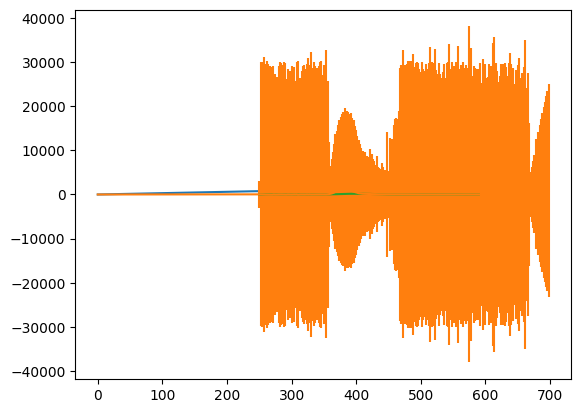

In [80]:
fig, ax = plt.subplots()
plt.plot(sorted_waves_led, ccd_power_led)
ax.errorbar(sorted_waves_lamp, ccd_power_lamp, yerr=ccd_pwr_error_lamp)
plt.plot(sorted_waves_dark[1:], led_subtract)